# ЛР6

## Упражнение

- Загрузите и нанесите на график исторические цены закрытия Tesla (``TSLA``) и Equinor (``EQNR``) за годы ``2019-12-31``- ``2022-12-31``.
- Для каждого временного ряда:
    - Проверьте, выглядит ли временной ряд стационарным.
    - Вычислите коэффициент Херста для обоих временных рядов.
    - В какие акции вы хотели бы инвестировать? Обоснуйте свой ответ на основе тестов и значения $H$.
    - Смоделируйте цены акций с помощью GBM.

- Какая симуляция кажется более надежной? Для Tesla или Equinor?
- Чтобы обосновать свой ответ:
1. вычислите симуляцию не менее 100 раз.
2. Вычислите MSE между истинными ценами акций и смоделированными.
3. Сравните ожидаемое значение MAPE для двух акций.

# _____________________________________________________________________

In [2]:
import sys
print(sys.executable)
!{sys.executable} -m pip install yfinance -q

c:\Users\RomanovHome\AppData\Local\Programs\Python\Python311\python.exe



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Импорты

In [3]:
import warnings
warnings.simplefilter(action="ignore", category=(FutureWarning, DeprecationWarning))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import yfinance as yf
np.random.seed(0)

def get_data(tickerSymbol, period, start, end):
    tickerData = yf.Ticker(tickerSymbol)
    tickerDf = tickerData.history(period=period, start=start, end=end)
    return tickerDf

def perform_adf_test(series, title, regression_type):
    out = adfuller(series, regression=regression_type)
    print(f"Результаты для {title}:")
    print(f'ADF Statistic: {out[0]:.2f}')
    print(f'p-value: {out[1]:.3f}')
    print(f"Critical Values: {[f'{k}: {r:.2f}' for r, k in zip(out[4].values(), out[4].keys())]}\n")

def hurst(ts):
    lags = range(2, 100)
    tau = [np.var(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] / 2.0



#### Шаг 1: Загрузка и визуализация данных

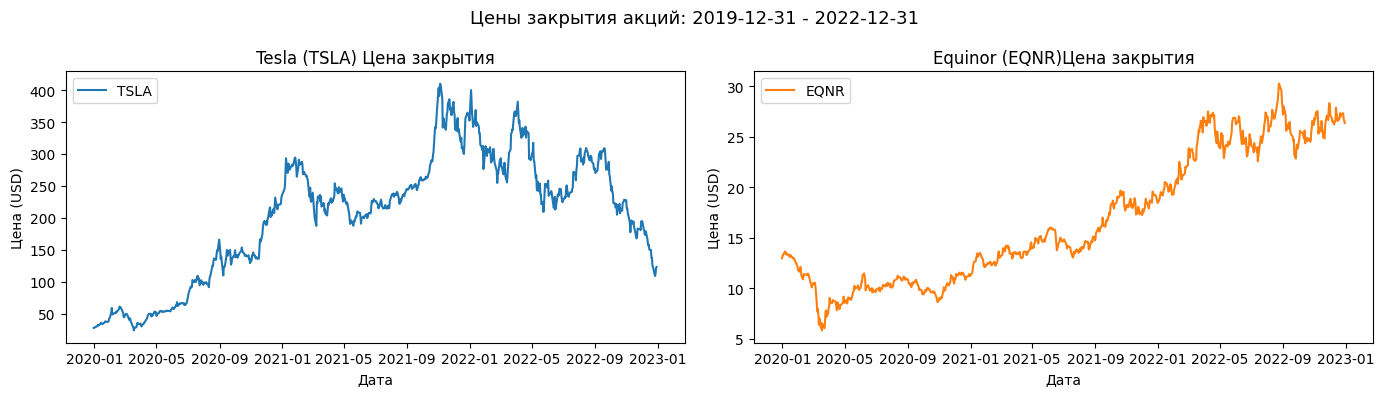

In [4]:
tsla_train = get_data('TSLA', period=None, start='2019-12-31', end='2022-12-31')
eqnr_train = get_data('EQNR', period=None, start='2019-12-31', end='2022-12-31')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tsla_train['Close'], color='tab:blue')
axes[0].set_title('Tesla (TSLA) Цена закрытия')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Цена (USD)')
axes[0].legend(['TSLA'], loc='upper left')

axes[1].plot(eqnr_train['Close'], color='tab:orange')
axes[1].set_title('Equinor (EQNR)Цена закрытия')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Цена (USD)')
axes[1].legend(['EQNR'], loc='upper left')

plt.suptitle('Цены закрытия акций: 2019-12-31 - 2022-12-31', fontsize=13)
plt.tight_layout()
plt.show()

у TSLA  явный тренд вверх, затем резкое падение.Ряд явно нестационарен (визуально), среднее и дисперсия меняются со временем

у EQNR более плавный восходящий тренд, без таких резких скачков. Тренд устойчив, но тоже нестационарен (визуально).

#### Шаг 2: Тест на единичный корень (ADF)

In [5]:
perform_adf_test(tsla_train['Close'], 'Tesla (TSLA)', 'ct')
perform_adf_test(eqnr_train['Close'], 'Equinor (EQNR)', 'ct')

Результаты для Tesla (TSLA):
ADF Statistic: -0.93
p-value: 0.953
Critical Values: ['1%: -3.97', '5%: -3.42', '10%: -3.13']

Результаты для Equinor (EQNR):
ADF Statistic: -3.60
p-value: 0.030
Critical Values: ['1%: -3.97', '5%: -3.42', '10%: -3.13']



TSLA: ADF=-0.93, p-value=0.953. Гипотеза о нестационарности не отвергается. Ряд содержит единичный корень (−0.93>−3.42)

EQNR: ADF=−3.60, p-value=0.030. Статистика пересекает критическое значение на уровне 5%(−3.42), p-value<0.05, H₀ отвергается. Формально ряд стационарен относительно тренда

#### Шаг 3: Показатель Херста

In [6]:
h_tsla = hurst(tsla_train['Close'].values)
h_eqnr = hurst(eqnr_train['Close'].values)

def classify_hurst(h):
    if h < 0.45:
        return "Возврат к среднему (H < 0.5)"
    elif h > 0.55:
        return "Трендовый (H > 0.5)"
    else:
        return "Близко к случайному блужданию (H ~~ 0.5)"

print(f"TSLA показатель Херста: {h_tsla:.4f} : {classify_hurst(h_tsla)}")
print(f"EQNR показатель Херста: {h_eqnr:.4f} : {classify_hurst(h_eqnr)}")

TSLA показатель Херста: 0.4626 : Близко к случайному блужданию (H ~~ 0.5)
EQNR показатель Херста: 0.3316 : Возврат к среднему (H < 0.5)


у TSLA h почти ровно на границе случайного блуждания. прошлые движения цены практически не влияют на будущие

а у EQNR h=0.33, явный возврат к среднему

#### Шаг 4: Во что бы инвестировал...

Вообще виуально, если смотреть на исходные графики закрытия акций - больше импонирует EQNR. Стабильный тренд без проседаний.

Теперь вывод на основе результатов ADF и показателя Херста

EQNR - ряд с возвратом к среднему. Это значит, что после сильного падения цена исторически возвращалась вверх, и наоборот. По ADF Нестационарность отвергается, у ряда есть структура и предсказуемость. Цена не дрейфует хаотично.

у TSLA  случайное блуждание. ADF не отвергает единичный корень. Исторические паттерны не дают преимущества, прошлое движение цены не несёт информации о будущем



#### Шаг 5: Моделирование GBM

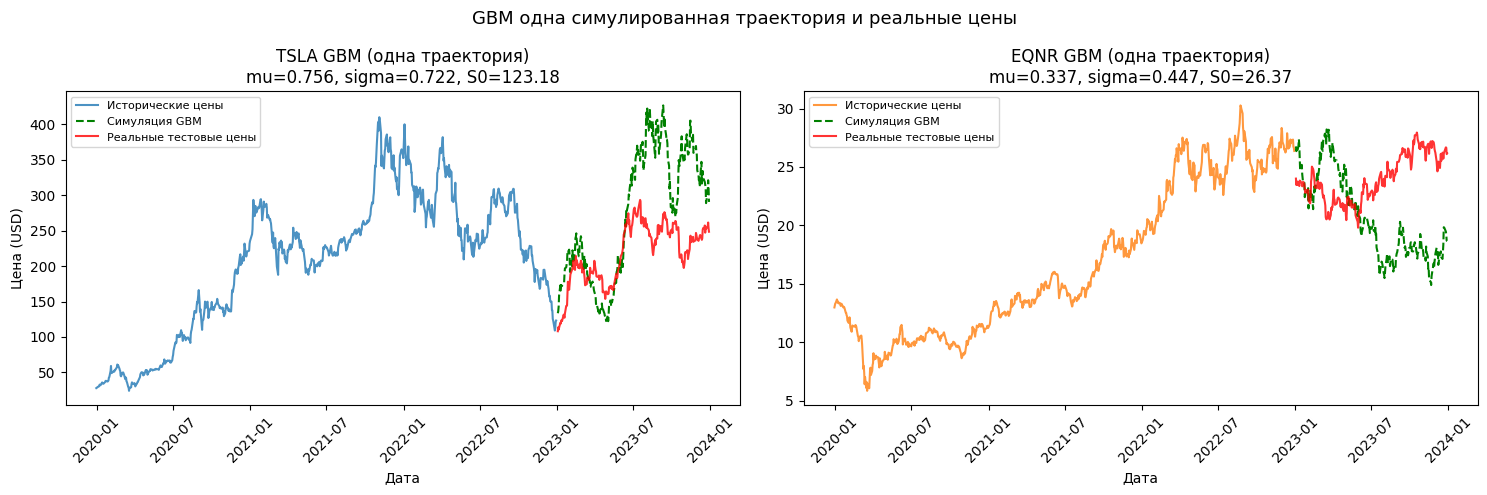

In [ ]:
np.random.seed(0) # для фиксирования начального состояния генератора случайных чисел(опционально)
tsla_test = get_data('TSLA', period=None, start='2022-12-31', end='2023-12-31')
eqnr_test = get_data('EQNR', period=None, start='2022-12-31', end='2023-12-31')

def simulate_gbm_single(train_close, test_days):
    returns = train_close.pct_change().dropna()
    mu    = returns.mean() * 252
    sigma = returns.std() * np.sqrt(252)
    S0    = train_close.iloc[-1]
    dt    = 1 / test_days
    N     = test_days
    time_step = np.linspace(0, 1, N)
    W = np.cumsum(np.random.standard_normal(size=N)) * np.sqrt(dt)
    X = (mu - 0.5 * sigma**2) * time_step + sigma * W
    return S0 * np.exp(X), mu, sigma, S0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (ticker, train, test, color) in zip(axes, [
    ('TSLA', tsla_train, tsla_test, 'tab:blue'),
    ('EQNR', eqnr_train, eqnr_test, 'tab:orange')
]):
    S, mu, sigma, S0 = simulate_gbm_single(train['Close'], len(test))
    ax.plot(train['Close'], label='Исторические цены', color=color, alpha=0.8)
    ax.plot(test.index, S, label='Симуляция GBM', color='green', linestyle='--')
    ax.plot(test['Close'], label='Реальные тестовые цены', color='red', alpha=0.8)
    ax.set_title(f'{ticker} GBM (одна траектория)\nmu={mu:.3f}, sigma={sigma:.3f}, S0={S0:.2f}')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Цена (USD)')
    ax.legend(loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('GBM одна симулированная траектория и реальные цены', fontsize=13)
plt.tight_layout()
plt.show()



![alt text](image.png)

mu (мю) - дрейф, ожидаемая годовая доходность
sigma - волатильность, годовое стандартное отклонение доходности
Sо - начальная цена

траектория GBM (один путь) выглядит как-то неправдоподобно и ненадежно, особено на TSLA, уж очень резский скачок...


#### Шаг 6: Множественные симуляции GBM

Множество путей формирует вероятностное распределение возможных будущих цен, а доверительный интервал показывает диапазон ожидаемых значений

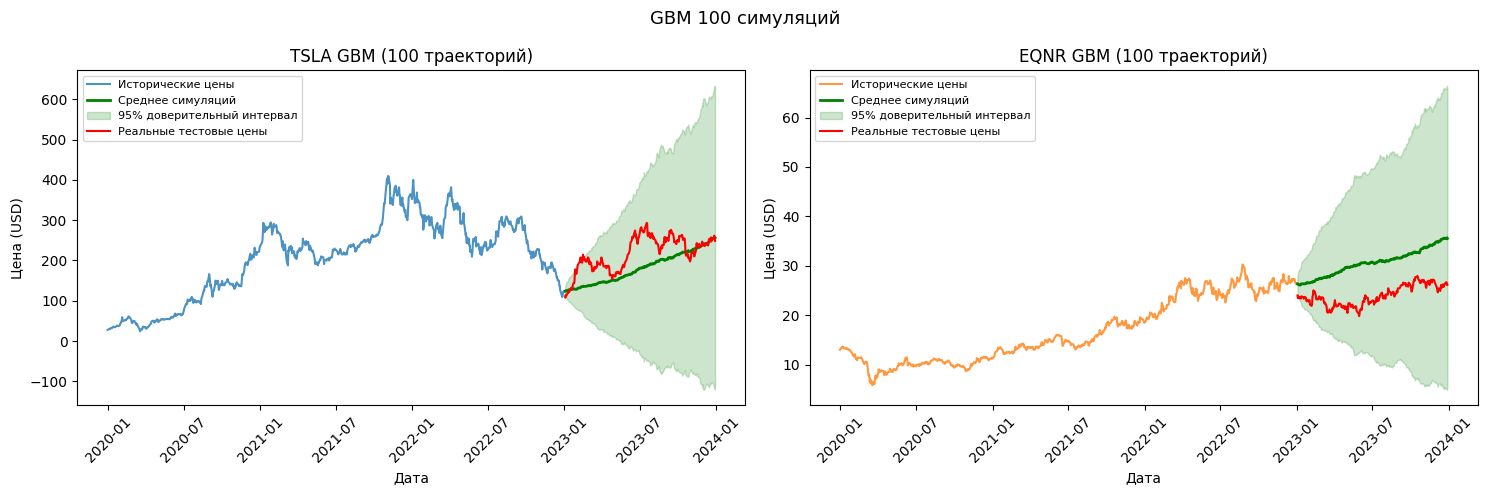

In [8]:
n_paths = 100

def simulate_gbm_multi(train_close, test_days, n_paths):
    returns = train_close.pct_change().dropna()
    mu    = returns.mean() * 252
    sigma = returns.std() * np.sqrt(252)
    S0    = train_close.iloc[-1]
    dt    = 1 / test_days
    N     = test_days
    time_step = np.linspace(0, 1, N)
    paths = []
    for _ in range(n_paths):
        W = np.cumsum(np.random.standard_normal(size=N)) * np.sqrt(dt)
        X = (mu - 0.5 * sigma**2) * time_step + sigma * W
        paths.append(S0 * np.exp(X))
    paths = np.array(paths)
    return paths, paths.mean(axis=0), paths.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (ticker, train, test, color) in zip(axes, [
    ('TSLA', tsla_train, tsla_test, 'tab:blue'),
    ('EQNR', eqnr_train, eqnr_test, 'tab:orange')
]):
    paths, path_mean, path_std = simulate_gbm_multi(train['Close'], len(test), n_paths)
    lower = path_mean - 1.96 * path_std
    upper = path_mean + 1.96 * path_std

    ax.plot(train['Close'], label='Исторические цены', color=color, alpha=0.8)
    ax.plot(test.index, path_mean, label='Среднее симуляций', color='green', linewidth=2)
    ax.fill_between(test.index, lower, upper, alpha=0.2, color='green',
                    label='95% доверительный интервал')
    ax.plot(test['Close'], label='Реальные тестовые цены', color='red', linewidth=1.5)
    ax.set_title(f'{ticker} GBM (100 траекторий)')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Цена (USD)')
    ax.legend(loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('GBM 100 симуляций', fontsize=13)
plt.tight_layout()
plt.show()

В обоих случаях красная линия держится в зеленой зоне. Но в TSLA интервал оч широкий от -100 ло 600, попадет любое поведение цены.

А в EQNR ситуация лучше. Красная линия идёт внутри интервала и держится близко к зелёному среднему, интервал узкий (если опячть же сравнивать с TSLA)

#### Шаг 7: MSE и MAPE, оценка качества

измеряем среднюю ошибку

In [9]:
np.random.seed(0)  # фиксируем

def compute_metrics(train_close, test_close, n_paths=100):
    returns = train_close.pct_change().dropna()
    mu    = returns.mean() * 252
    sigma = returns.std() * np.sqrt(252)
    S0    = train_close.iloc[-1]
    test_days = len(test_close)
    dt    = 1 / test_days
    N     = test_days
    time_step = np.linspace(0, 1, N)
    real = test_close.values

    mse_list, mape_list = [], []
    for _ in range(n_paths):
        W = np.cumsum(np.random.standard_normal(size=N)) * np.sqrt(dt)
        X = (mu - 0.5 * sigma**2) * time_step + sigma * W
        sim = S0 * np.exp(X)
        mse_list.append(np.mean((real - sim) ** 2))
        mape_list.append(np.mean(np.abs(real - sim) / np.abs(real)) * 100)

    return np.mean(mse_list), np.mean(mape_list)

e_mse_tsla, e_mape_tsla = compute_metrics(tsla_train['Close'], tsla_test['Close'])
e_mse_eqnr, e_mape_eqnr = compute_metrics(eqnr_train['Close'], eqnr_test['Close'])

results_df = pd.DataFrame({
    'Актив':    ['TSLA (Tesla)', 'EQNR (Equinor)'],
    'E[MSE]':   [f'{e_mse_tsla:.2f}', f'{e_mse_eqnr:.2f}'],
    'E[MAPE], %': [f'{e_mape_tsla:.2f}%', f'{e_mape_eqnr:.2f}%']
})
print(results_df.to_string(index=False))

         Актив   E[MSE] E[MAPE], %
  TSLA (Tesla) 15370.24     41.33%
EQNR (Equinor)   152.47     37.17%


TSLA: в среднем симуляция ошибается на 41% от реальной цены. MSE огромный из-за квадратичного масштаба цен и большого разброса траекторий;
У EQNR: симуляция ошибается на 37%, чуть лучше TSLA, MSE на два порядка меньше;

y EQNR моделируется надёжнее по обоим метрикам, особенно заметно по MSE, разница в 100 раз. MAPE отличается меньше (41%/37%)